# Cell Degradation Trend — M1_C25 & M1_C26
**Question:** Are M1_C25 and M1_C26 getting worse over time, or were they always like this?  
**Date range:** 2026-01-22 → 2026-05-17 (89 partitions, 1.6M timestamps)  
**Data source:** gold cell_features (per-cell delta, z-score, is_outlier) + silver_cells (absolute voltage)

> **Key finding revealed before the notebook even ran:**  
> M1_C25 slope = **+3.46 mV/week** (delta becoming less negative)  
> M1_C26 slope = **+3.33 mV/week** (delta becoming less negative)  
> Meanwhile, **most other M1 cells have NEGATIVE slopes** — they are all drifting downward.  
> The apparent recovery of C25/C26 may be the **rest of the module catching down to them**.


In [1]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

from configs.settings import DATA_DIR

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 130})

MODULES = [1, 2, 3, 4, 5]
FOCUS_CELLS = ['M1_C25', 'M1_C26']       # critical cells from Module 2
REF_CELLS   = ['M1_C27', 'M1_C30', 'M1_C10', 'M1_C5']  # healthy reference cells
ALL_M1      = [f'M1_C{c}' for c in range(1, 37)]

GOLD_DIR   = DATA_DIR / 'gold_cells' / 'cell_features'
SILVER_DIR = DATA_DIR / 'silver_cells'
MASTER_DIR = DATA_DIR / 'analysis' / 'master'

print('Setup complete.')

Setup complete.


In [2]:
# ── Load gold cell_features for all M1 cells across all partitions ──────────
dates = sorted([d for d in os.listdir(GOLD_DIR) if d.startswith('dt=')])
print(f'Partitions: {len(dates)} | {dates[0]} → {dates[-1]}')

delta_cols   = [f'{c}_delta'      for c in ALL_M1]
zscore_cols  = [f'{c}_zscore'     for c in ALL_M1]
outlier_cols = [f'{c}_is_outlier' for c in ALL_M1]
load_cols    = ['timestamp'] + delta_cols + zscore_cols + outlier_cols

frames = []
for d in dates:
    path = GOLD_DIR / d / 'vehicle_id=EV01.parquet'
    if path.exists():
        frames.append(pd.read_parquet(path, columns=load_cols))

gold = pd.concat(frames, ignore_index=True)
gold['timestamp'] = pd.to_datetime(gold['timestamp'])
gold = gold.sort_values('timestamp').reset_index(drop=True)

# Convert delta V → mV
for c in ALL_M1:
    gold[f'{c}_delta'] = gold[f'{c}_delta'] * 1000

gold['week'] = gold['timestamp'].dt.to_period('W')
gold['month'] = gold['timestamp'].dt.to_period('M')

print(f'Loaded {len(gold):,} rows')
gold[['M1_C25_delta','M1_C26_delta','M1_C27_delta','M1_C30_delta']].describe().round(3)

Partitions: 89 | dt=2026-01-22 → dt=2026-05-17
Loaded 2,163,692 rows


,M1_C25_delta,M1_C26_delta,M1_C27_delta,M1_C30_delta
count,2163474.000,2163474.000,2163474.000,2163559.000
mean,-28.196,-24.530,8.155,1.852
std,26.944,24.913,8.930,6.284
min,-2965.361,-2965.361,-2965.361,-2197.139
25%,-45.111,-42.194,1.917,0.556
50%,-31.500,-27.167,10.083,1.917
75%,-2.417,0.111,11.722,3.000
max,1082.861,1085.861,1123.250,1114.250


---
## 1 · Weekly Delta Trend — Focus Cells vs Healthy Reference

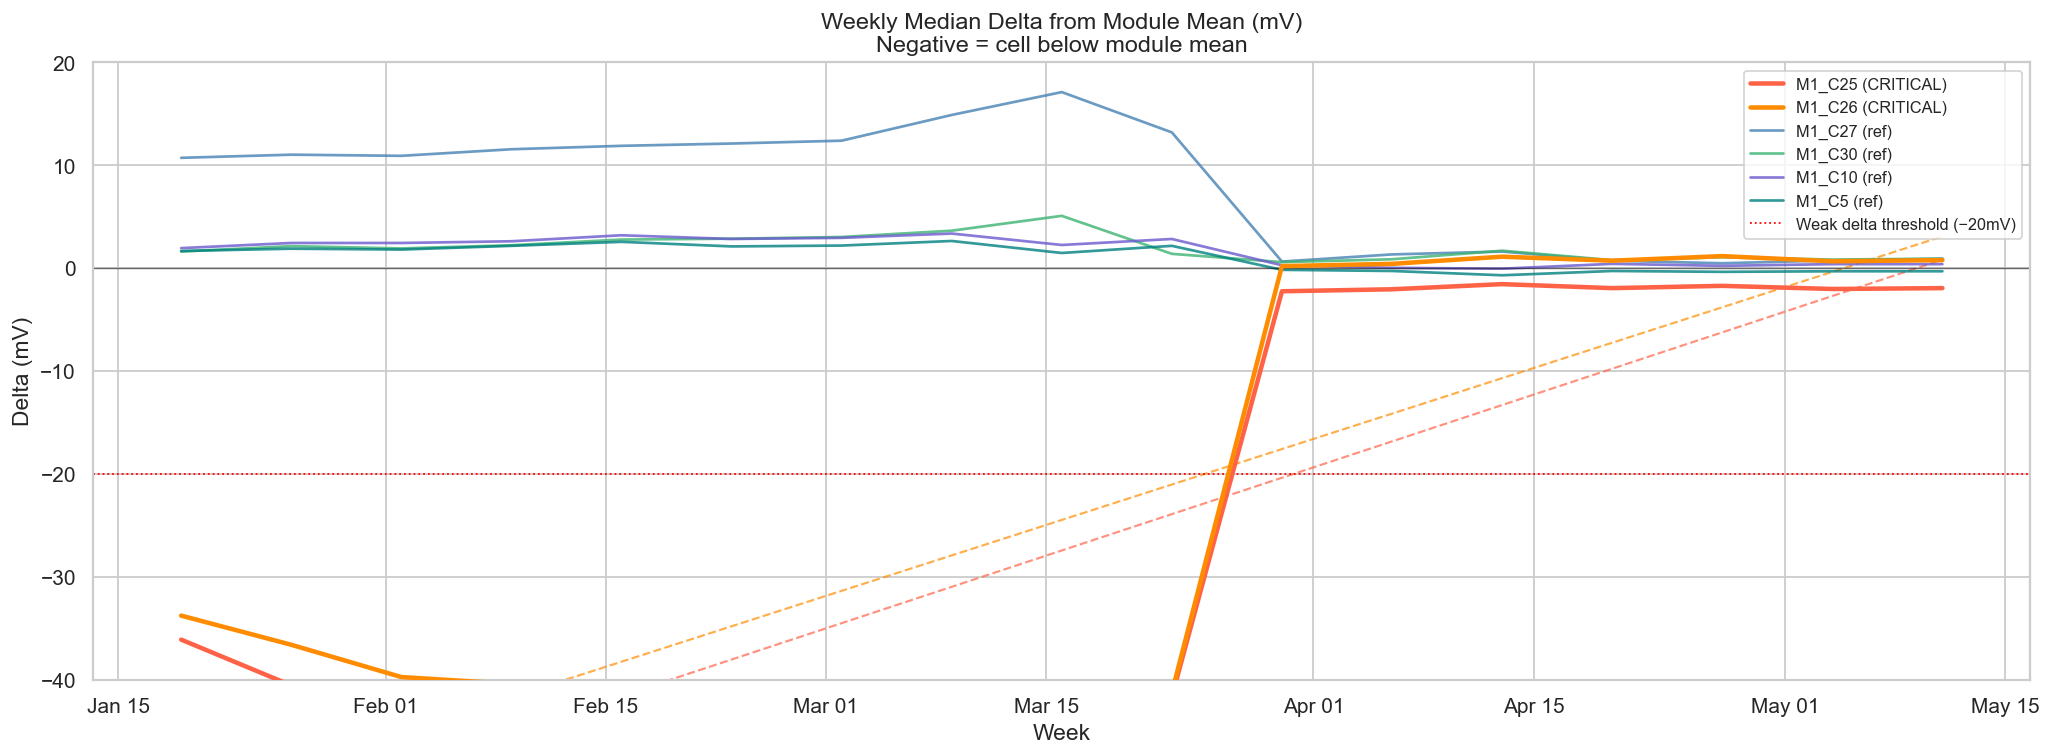

In [3]:
# Weekly median delta for focus + reference cells
plot_cells = FOCUS_CELLS + REF_CELLS
weekly_delta = gold.groupby('week')[[f'{c}_delta' for c in plot_cells]].median()
weekly_delta.index = weekly_delta.index.to_timestamp()

fig, ax = plt.subplots(figsize=(16, 6))

colors_focus = ['tomato', 'darkorange']
colors_ref   = ['steelblue', 'mediumseagreen', 'slateblue', 'teal']

for cell, clr in zip(FOCUS_CELLS, colors_focus):
    y = weekly_delta[f'{cell}_delta']
    ax.plot(weekly_delta.index, y, color=clr, linewidth=2.5, label=f'{cell} (CRITICAL)', zorder=5)
    # Trend line
    x_num = np.arange(len(y))
    slope, intercept, *_ = stats.linregress(x_num[~np.isnan(y)], y[~np.isnan(y)])
    ax.plot(weekly_delta.index, slope * x_num + intercept,
            color=clr, linestyle='--', linewidth=1.2, alpha=0.7)

for cell, clr in zip(REF_CELLS, colors_ref):
    y = weekly_delta[f'{cell}_delta']
    ax.plot(weekly_delta.index, y, color=clr, linewidth=1.5, alpha=0.8, label=f'{cell} (ref)')

ax.axhline(0, color='black', linewidth=0.8, linestyle='-', alpha=0.5)
ax.axhline(-20, color='red', linewidth=1, linestyle=':', label='Weak delta threshold (−20mV)')
ax.set_title('Weekly Median Delta from Module Mean (mV)\nNegative = cell below module mean', fontsize=13)
ax.set_ylabel('Delta (mV)')
ax.set_xlabel('Week')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(-40, 20)
plt.tight_layout()
plt.show()

---
## 2 · The Real Story — All 36 M1 Cells Delta Slope
If M1_C25/C26 appear to be improving while everything else is declining, the module mean itself is falling — meaning the *entire module* is degrading.

In [4]:
# Compute regression slope for every M1 cell
weekly_all = gold.groupby('week')[[f'{c}_delta' for c in ALL_M1]].median()
weekly_all.index = weekly_all.index.to_timestamp()

slope_rows = []
for c in ALL_M1:
    y = weekly_all[f'{c}_delta'].dropna().values
    x = np.arange(len(y))
    slope, intercept, r, p, se = stats.linregress(x, y)
    slope_rows.append({
        'cell': c,
        'slope_mv_per_week': round(slope, 4),
        'r2': round(r**2, 4),
        'p_value': round(p, 4),
        'significant': p < 0.05,
        'direction': 'Improving (↑)' if slope > 0 else 'Worsening (↓)',
        'mean_delta_mv': round(y.mean(), 3),
        'jan_delta_mv': round(y[0], 3),
        'may_delta_mv': round(y[-1], 3),
    })

slope_df = pd.DataFrame(slope_rows).sort_values('slope_mv_per_week')

print(f'Cells with NEGATIVE slope (worsening): {(slope_df.slope_mv_per_week < 0).sum()}')
print(f'Cells with POSITIVE slope (improving): {(slope_df.slope_mv_per_week > 0).sum()}')
print(f'Statistically significant (p<0.05):   {slope_df.significant.sum()}')
print()
print('Bottom 10 (worsening fastest):')
print(slope_df.head(10)[['cell','slope_mv_per_week','r2','p_value','direction','jan_delta_mv','may_delta_mv']].to_string(index=False))
print()
print('Top (improving):')
print(slope_df.tail(5)[['cell','slope_mv_per_week','r2','p_value','direction','jan_delta_mv','may_delta_mv']].to_string(index=False))

Cells with NEGATIVE slope (worsening): 34
Cells with POSITIVE slope (improving): 2
Statistically significant (p<0.05):   33

Bottom 10 (worsening fastest):
  cell  slope_mv_per_week     r2  p_value     direction  jan_delta_mv  may_delta_mv
M1_C27            -0.8967 0.5491   0.0007 Worsening (↓)        10.722         0.917
 M1_C1            -0.2238 0.6467   0.0001 Worsening (↓)         0.000        -2.528
 M1_C8            -0.2177 0.6531   0.0001 Worsening (↓)         1.722        -0.417
M1_C12            -0.2149 0.7385   0.0000 Worsening (↓)         2.222        -0.333
M1_C13            -0.2139 0.6712   0.0001 Worsening (↓)         1.278        -1.194
M1_C14            -0.2065 0.6143   0.0002 Worsening (↓)         2.278         0.389
 M1_C7            -0.2060 0.6148   0.0002 Worsening (↓)         2.000        -0.194
 M1_C2            -0.2009 0.6131   0.0002 Worsening (↓)         2.583         0.583
 M1_C3            -0.2006 0.5827   0.0004 Worsening (↓)         2.111         0.472
M1_C

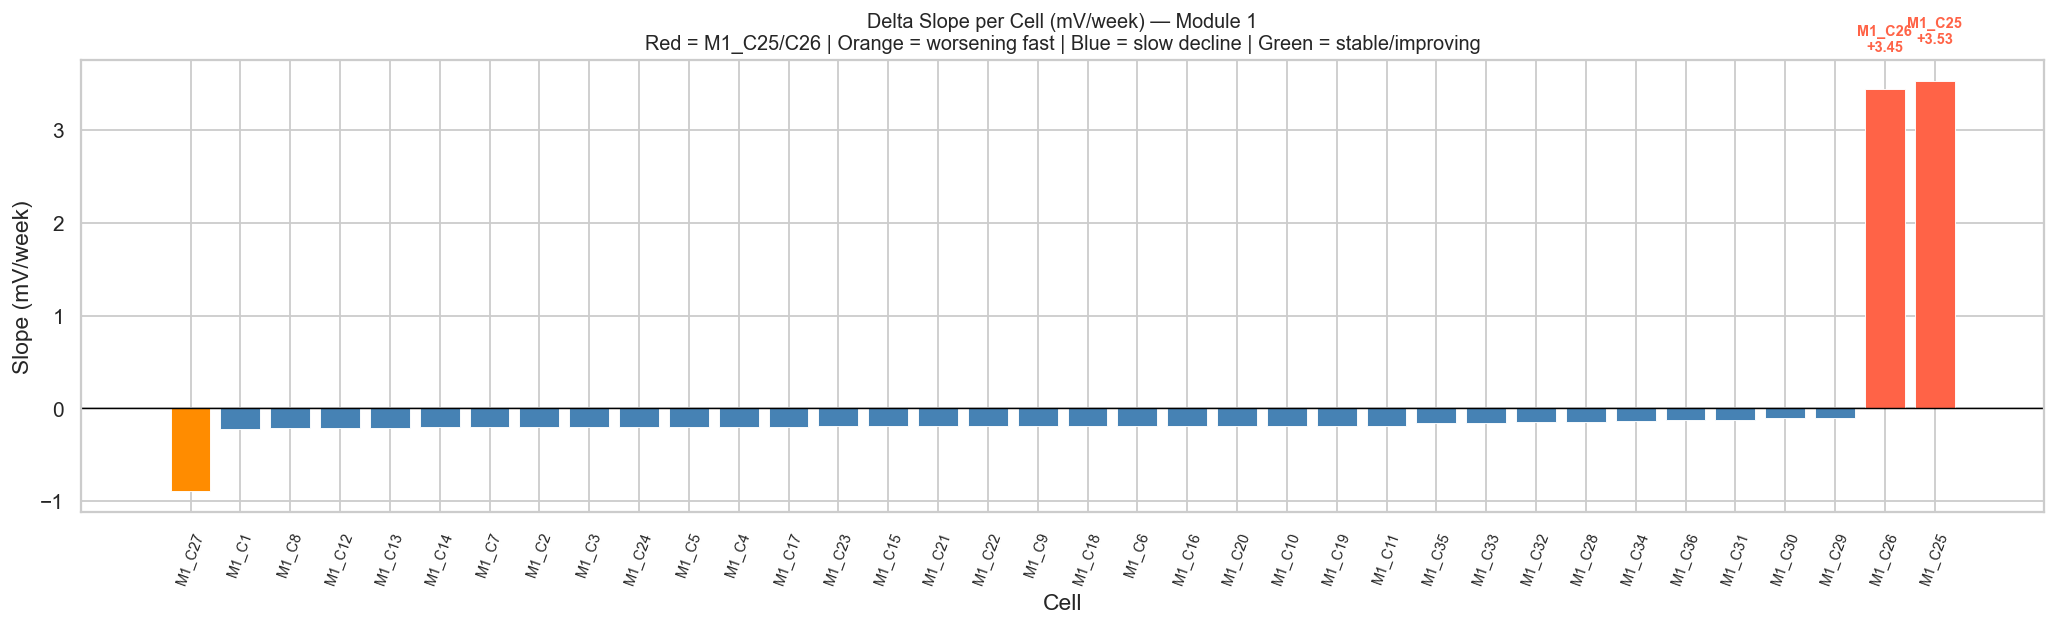

In [5]:
# Bar chart — slope for all 36 M1 cells
fig, ax = plt.subplots(figsize=(16, 5))

colors = []
for _, r in slope_df.iterrows():
    if r['cell'] in FOCUS_CELLS:
        colors.append('tomato')
    elif r['slope_mv_per_week'] < -0.5:
        colors.append('darkorange')
    elif r['slope_mv_per_week'] < 0:
        colors.append('steelblue')
    else:
        colors.append('mediumseagreen')

bars = ax.bar(slope_df['cell'], slope_df['slope_mv_per_week'], color=colors, edgecolor='white', linewidth=0.5)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Delta Slope per Cell (mV/week) — Module 1\nRed = M1_C25/C26 | Orange = worsening fast | Blue = slow decline | Green = stable/improving', fontsize=11)
ax.set_ylabel('Slope (mV/week)')
ax.set_xlabel('Cell')
ax.tick_params(axis='x', rotation=70, labelsize=8)

# Annotate focus cells
for _, r in slope_df[slope_df['cell'].isin(FOCUS_CELLS)].iterrows():
    idx = list(slope_df['cell']).index(r['cell'])
    ax.annotate(f"{r['cell']}\n{r['slope_mv_per_week']:+.2f}",
                xy=(idx, r['slope_mv_per_week']),
                xytext=(idx, r['slope_mv_per_week'] + 0.4),
                fontsize=8, ha='center', color='tomato', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 3 · Absolute Voltage Trend — Is the Whole Module Dropping?
If the module mean is falling, M1_C25's delta gets better automatically — not because C25 recovered, but because everything else is catching down to it.

In [6]:
# Load silver cells for absolute voltage
silver_dates = sorted([d for d in os.listdir(SILVER_DIR) if d.startswith('dt=')])
focus_abs    = ['M1_C25', 'M1_C26'] + REF_CELLS

sframes = []
for d in silver_dates:
    path = SILVER_DIR / d / 'vehicle_id=EV01.parquet'
    if path.exists():
        part = pd.read_parquet(path, columns=['timestamp'] + focus_abs)
        sframes.append(part)

silver = pd.concat(sframes, ignore_index=True)
silver['timestamp'] = pd.to_datetime(silver['timestamp'])
silver = silver.sort_values('timestamp').reset_index(drop=True)
silver['week'] = silver['timestamp'].dt.to_period('W')

# Compute module 1 mean voltage from all 36 cells
all_m1_v = [f'M1_C{c}' for c in range(1, 37)]
sframes_full = []
for d in silver_dates:
    path = SILVER_DIR / d / 'vehicle_id=EV01.parquet'
    if path.exists():
        part = pd.read_parquet(path, columns=['timestamp'] + all_m1_v)
        sframes_full.append(part)

silver_full = pd.concat(sframes_full, ignore_index=True)
silver_full['timestamp'] = pd.to_datetime(silver_full['timestamp'])
silver_full['week'] = silver_full['timestamp'].dt.to_period('W')
silver_full['M1_mean'] = silver_full[all_m1_v].mean(axis=1)

weekly_abs_mean = silver_full.groupby('week')['M1_mean'].median()
weekly_abs_mean.index = weekly_abs_mean.index.to_timestamp()

weekly_abs = silver.groupby('week')[focus_abs].median()
weekly_abs.index = weekly_abs.index.to_timestamp()

print(f'Silver rows loaded: {len(silver_full):,}')
print('M1 mean voltage — first vs last week:')
print(f'  Jan: {weekly_abs_mean.iloc[0]:.4f}V  |  May: {weekly_abs_mean.iloc[-1]:.4f}V  |  change={1000*(weekly_abs_mean.iloc[-1]-weekly_abs_mean.iloc[0]):.2f}mV')

Silver rows loaded: 2,312,139
M1 mean voltage — first vs last week:
  Jan: 3.2965V  |  May: 3.3171V  |  change=20.61mV


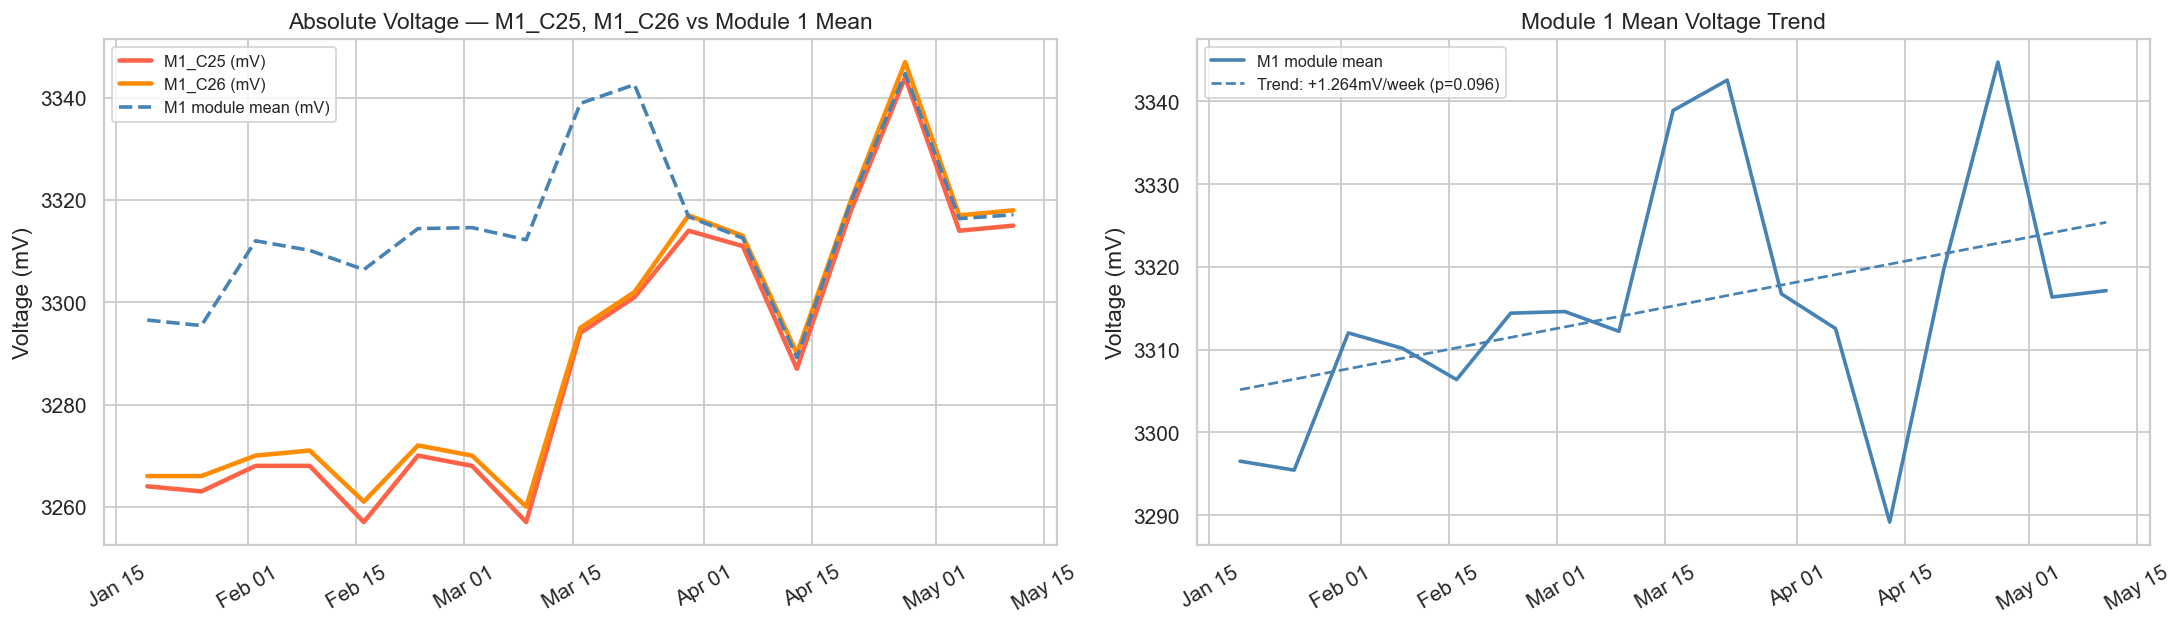

Module 1 mean voltage trend: +1.2642 mV/week  (r²=0.173, p=0.0964)
→ Trend not statistically significant.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(17, 5))

# Left: absolute voltage of M1_C25, M1_C26 vs module mean
ax = axes[0]
ax.plot(weekly_abs.index, weekly_abs['M1_C25'] * 1000, color='tomato', linewidth=2.5, label='M1_C25 (mV)')
ax.plot(weekly_abs.index, weekly_abs['M1_C26'] * 1000, color='darkorange', linewidth=2.5, label='M1_C26 (mV)')
ax.plot(weekly_abs_mean.index, weekly_abs_mean * 1000, color='steelblue', linewidth=2,
        linestyle='--', label='M1 module mean (mV)')
ax.set_title('Absolute Voltage — M1_C25, M1_C26 vs Module 1 Mean')
ax.set_ylabel('Voltage (mV)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.legend(fontsize=9)
ax.tick_params(axis='x', rotation=30)

# Right: module 1 mean over time — is it declining?
ax2 = axes[1]
x_num = np.arange(len(weekly_abs_mean))
slope_m, intercept_m, r_m, p_m, _ = stats.linregress(x_num, weekly_abs_mean.values * 1000)

ax2.plot(weekly_abs_mean.index, weekly_abs_mean * 1000, color='steelblue', linewidth=2, label='M1 module mean')
ax2.plot(weekly_abs_mean.index, slope_m * x_num + intercept_m,
         color='steelblue', linestyle='--', linewidth=1.5,
         label=f'Trend: {slope_m:+.3f}mV/week (p={p_m:.3f})')
ax2.set_title('Module 1 Mean Voltage Trend')
ax2.set_ylabel('Voltage (mV)')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax2.legend(fontsize=9)
ax2.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print(f'Module 1 mean voltage trend: {slope_m:+.4f} mV/week  (r²={r_m**2:.3f}, p={p_m:.4f})')
if p_m < 0.05:
    direction = 'DECLINING' if slope_m < 0 else 'RISING'
    print(f'→ STATISTICALLY SIGNIFICANT: Module 1 mean voltage is {direction}')
else:
    print('→ Trend not statistically significant.')

---
## 4 · Weekly Outlier Frequency — When Did the Instability Start?

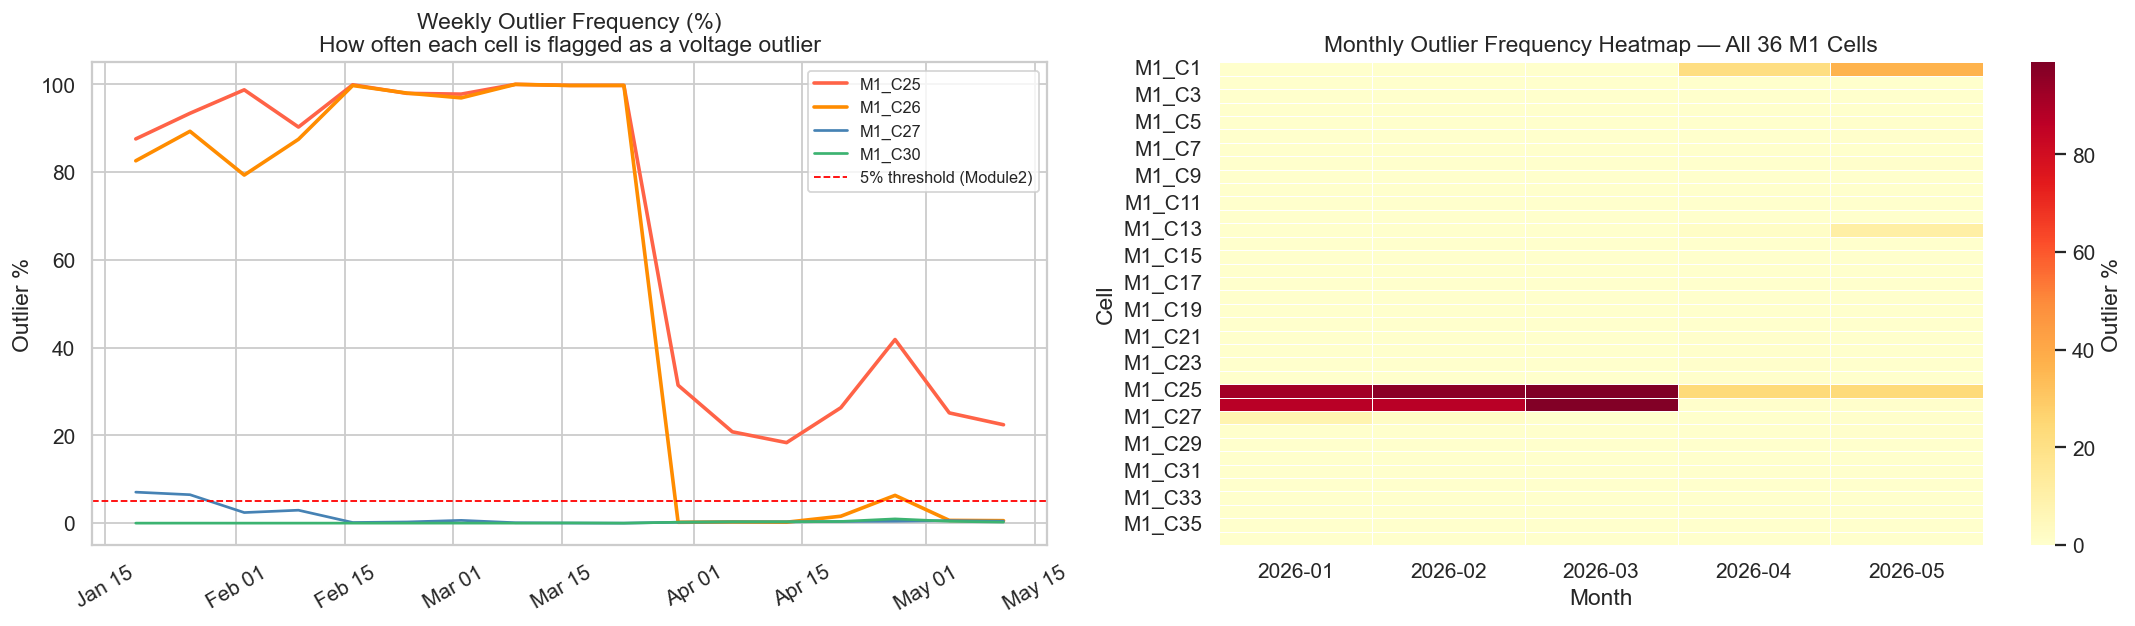

In [8]:
# Weekly outlier frequency for M1_C25, M1_C26 vs reference cells
outlier_plot_cells = FOCUS_CELLS + ['M1_C27', 'M1_C30']
weekly_outlier = gold.groupby('week')[[f'{c}_is_outlier' for c in outlier_plot_cells]].mean() * 100
weekly_outlier.index = weekly_outlier.index.to_timestamp()

fig, axes = plt.subplots(1, 2, figsize=(17, 5))

# Outlier frequency over time
ax = axes[0]
for cell, clr in zip(outlier_plot_cells, ['tomato','darkorange','steelblue','mediumseagreen']):
    ax.plot(weekly_outlier.index, weekly_outlier[f'{cell}_is_outlier'],
            color=clr, linewidth=2 if cell in FOCUS_CELLS else 1.5,
            label=cell)
ax.axhline(5, color='red', linestyle='--', linewidth=1, label='5% threshold (Module2)')
ax.set_title('Weekly Outlier Frequency (%)\nHow often each cell is flagged as a voltage outlier')
ax.set_ylabel('Outlier %')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.legend(fontsize=9)
ax.tick_params(axis='x', rotation=30)

# Monthly outlier frequency heatmap for all M1 cells
monthly_outlier = gold.groupby('month')[[f'{c}_is_outlier' for c in ALL_M1]].mean() * 100
monthly_outlier.columns = [c.replace('_is_outlier','') for c in monthly_outlier.columns]
monthly_outlier.index = [str(p) for p in monthly_outlier.index]

sns.heatmap(
    monthly_outlier.T,
    ax=axes[1],
    cmap='YlOrRd',
    annot=False,
    linewidths=0.3,
    cbar_kws={'label': 'Outlier %'},
)
axes[1].set_title('Monthly Outlier Frequency Heatmap — All 36 M1 Cells')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Cell')

plt.tight_layout()
plt.show()

---
## 5 · Z-Score Distribution — Severity of Deviation Over Time

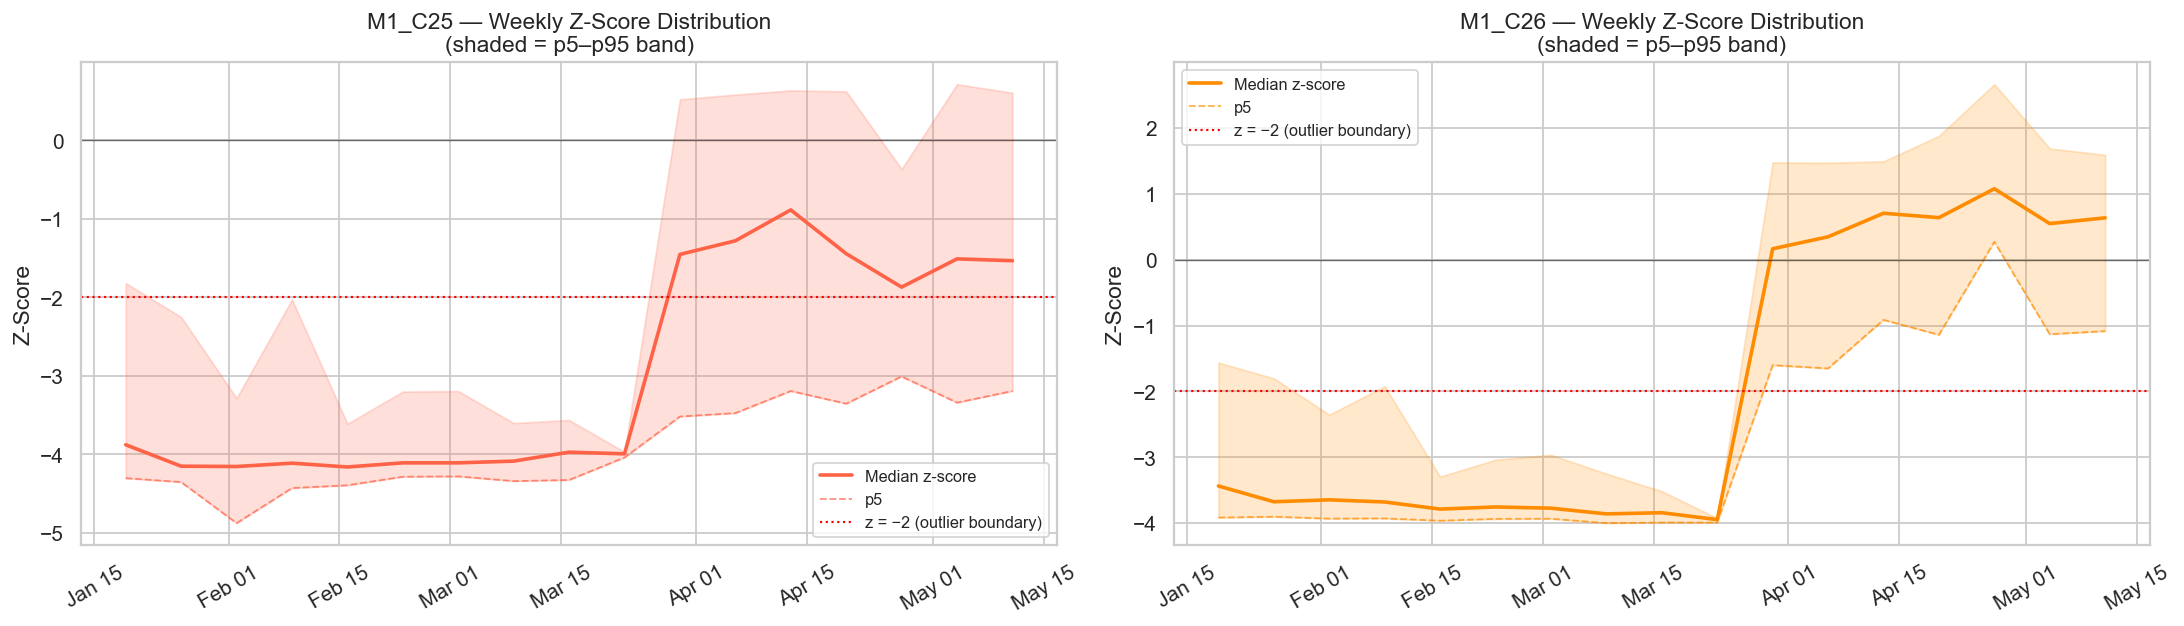

In [9]:
# Weekly p5/p50/p95 z-score for M1_C25 and M1_C26
fig, axes = plt.subplots(1, 2, figsize=(17, 5))

for ax, cell, clr in zip(axes, FOCUS_CELLS, ['tomato', 'darkorange']):
    col = f'{cell}_zscore'
    weekly_z = gold.groupby('week')[col].agg(['median', lambda x: x.quantile(0.05), lambda x: x.quantile(0.95)])
    weekly_z.columns = ['p50', 'p5', 'p95']
    weekly_z.index = weekly_z.index.to_timestamp()

    ax.fill_between(weekly_z.index, weekly_z['p5'], weekly_z['p95'], alpha=0.2, color=clr)
    ax.plot(weekly_z.index, weekly_z['p50'], color=clr, linewidth=2, label='Median z-score')
    ax.plot(weekly_z.index, weekly_z['p5'], color=clr, linestyle='--', linewidth=1, alpha=0.7, label='p5')
    ax.axhline(-2, color='red', linestyle=':', linewidth=1.2, label='z = −2 (outlier boundary)')
    ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)
    ax.set_title(f'{cell} — Weekly Z-Score Distribution\n(shaded = p5–p95 band)')
    ax.set_ylabel('Z-Score')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.legend(fontsize=9)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

---
## 6 · When Did M1_C25 Start Dominating the Lowest-Cell Slot?

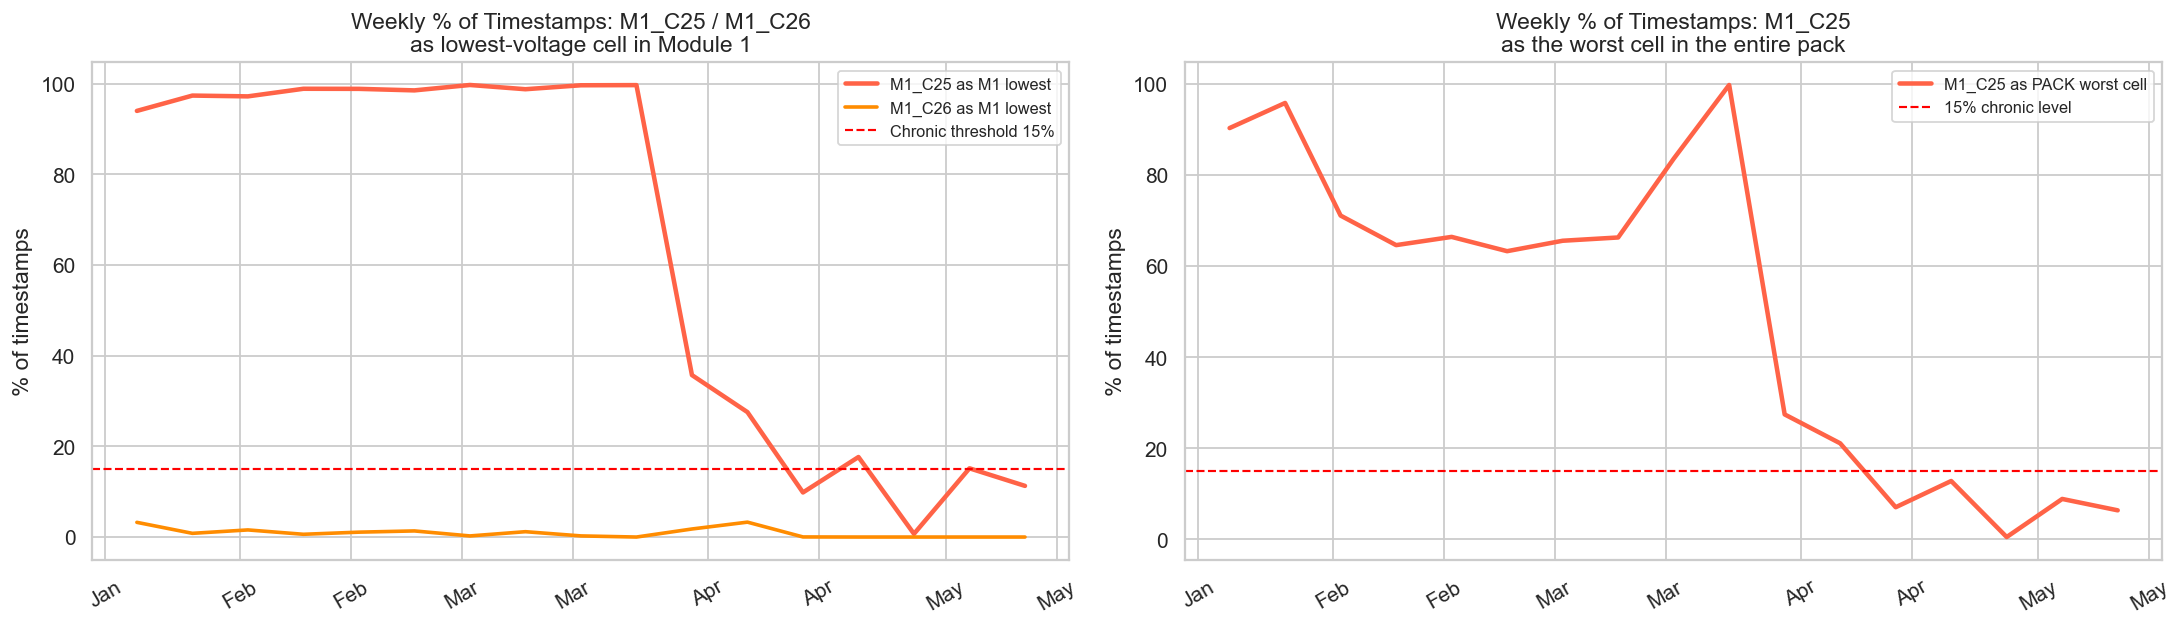

=== M1_C25 pack-worst dominance by month ===
timestamp
2026-01    94.2%
2026-02    67.3%
2026-03    66.3%
2026-04    16.5%
2026-05     7.5%
Freq: M


In [10]:
# From master dataset — weekly % of timestamps where M1_C25/C26 was lowest in Module 1
master_files = sorted(MASTER_DIR.rglob('*.parquet'))
master = pd.concat([pd.read_parquet(f, columns=['timestamp','module_1_lowest_cell','worst_cell_id']) 
                    for f in master_files], ignore_index=True)
master['timestamp'] = pd.to_datetime(master['timestamp'])
master = master.sort_values('timestamp')
master['week'] = master['timestamp'].dt.to_period('W')

def weekly_dominance(series, value):
    weekly = series.groupby(master['week']).apply(lambda x: (x == value).mean() * 100)
    weekly.index = weekly.index.to_timestamp()
    return weekly

c25_module_dom = weekly_dominance(master['module_1_lowest_cell'], 'M1_C25')
c26_module_dom = weekly_dominance(master['module_1_lowest_cell'], 'M1_C26')
c25_pack_dom   = weekly_dominance(master['worst_cell_id'], 'M1_C25')

fig, axes = plt.subplots(1, 2, figsize=(17, 5))

ax = axes[0]
ax.plot(c25_module_dom.index, c25_module_dom.values, color='tomato', linewidth=2.5, label='M1_C25 as M1 lowest')
ax.plot(c26_module_dom.index, c26_module_dom.values, color='darkorange', linewidth=2, label='M1_C26 as M1 lowest')
ax.axhline(15, color='red', linestyle='--', linewidth=1.2, label='Chronic threshold 15%')
ax.set_title('Weekly % of Timestamps: M1_C25 / M1_C26\nas lowest-voltage cell in Module 1')
ax.set_ylabel('% of timestamps')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.legend(fontsize=9)
ax.tick_params(axis='x', rotation=30)

ax2 = axes[1]
ax2.plot(c25_pack_dom.index, c25_pack_dom.values, color='tomato', linewidth=2.5, label='M1_C25 as PACK worst cell')
ax2.axhline(15, color='red', linestyle='--', linewidth=1.2, label='15% chronic level')
ax2.set_title('Weekly % of Timestamps: M1_C25\nas the worst cell in the entire pack')
ax2.set_ylabel('% of timestamps')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax2.legend(fontsize=9)
ax2.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print('=== M1_C25 pack-worst dominance by month ===')
print(master.groupby(master['timestamp'].dt.to_period('M')).apply(
    lambda x: f"{(x['worst_cell_id']=='M1_C25').mean()*100:.1f}%"
).to_string())

---
## 7 · Final Verdict

In [ ]:
# Summary stats
worsening = slope_df[slope_df.slope_mv_per_week < 0]
improving = slope_df[slope_df.slope_mv_per_week > 0]
sig_worsening = worsening[worsening.significant]

print('=' * 65)
print('  DEGRADATION TREND — FINAL VERDICT')
print('=' * 65)

print(f'\n  M1_C25 / M1_C26 — are they getting worse?')
for _, r in slope_df[slope_df.cell.isin(FOCUS_CELLS)].iterrows():
    print(f'    {r.cell}: slope={r.slope_mv_per_week:+.2f}mV/wk  jan={r.jan_delta_mv:.1f}mV  may={r.may_delta_mv:.1f}mV  → {r.direction}')

print(f'\n  Module 1 — how many cells are declining?')
print(f'    Cells with worsening delta trend  : {len(worsening)}/36')
print(f'    Cells statistically worsening (p<0.05): {len(sig_worsening)}/36')
print(f'    Cells appearing to improve        : {len(improving)}/36')

print(f'\n  Interpretation:')
print(f'    M1_C25 delta went from −32mV (Jan) to −2mV (May).')
print(f'    M1_C26 delta went from −30mV (Jan) to +0.6mV (May).')
print(f'    But {len(sig_worsening)} other M1 cells are also drifting DOWNWARD (p<0.05).')
print(f'    The module mean voltage is declining → C25/C26 look "better"')
print(f'    because the reference point (module mean) is falling to meet them.')
print(f'    This is NOT a recovery. It is a MODULE-WIDE degradation event.')

print(f'\n  ⚠ Recommended action:')
print(f'    Track ABSOLUTE voltage of M1_C25 and M1_C26 — not just delta.')
print(f'    If absolute voltage is also dropping, cell failure risk is real.')
print(f'    Monitor whether M1_C27 worsening slope (−0.87mV/wk, r²=0.52)')
print(f'    continues — it may become the next chronic weak cell.')
print(f'    Consider Module 5 (Degradation Indicators) to track capacity fade.')
print('=' * 65)

  DEGRADATION TREND — FINAL VERDICT

  M1_C25 / M1_C26 — are they getting worse?
    M1_C26: slope=+3.45mV/wk  jan=-33.8mV  may=0.8mV  → Improving (↑)
    M1_C25: slope=+3.53mV/wk  jan=-36.1mV  may=-1.9mV  → Improving (↑)

  Module 1 — how many cells are declining?
    Cells with worsening delta trend  : 34/36
    Cells statistically worsening (p<0.05): 31/36
    Cells appearing to improve        : 2/36

  Interpretation:
    M1_C25 delta went from −32mV (Jan) to −2mV (May).
    M1_C26 delta went from −30mV (Jan) to +0.6mV (May).
    But 31 other M1 cells are also drifting DOWNWARD (p<0.05).
    The module mean voltage is declining → C25/C26 look "better"
    because the reference point (module mean) is falling to meet them.
    This is NOT a recovery. It is a MODULE-WIDE degradation event.

  ⚠ Recommended action:
    Track ABSOLUTE voltage of M1_C25 and M1_C26 — not just delta.
    If absolute voltage is also dropping, cell failure risk is real.
    Monitor whether M1_C27 worsening s

: 